# Stunting Prediction — Linear Regression Task


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Preprocessed Data.xlsx'

df = pd.read_excel(DRIVE_PATH)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
df.head()

Mounted at /content/drive
Shape: (40071, 11)

Columns: ['No.', 'Gender', 'Age (Month)', 'Weight', 'Height', 'Weight for Age', 'Z-Score  W/A', 'Height for Age', 'Z-Score H/A', 'Weight for Height', 'Z-Score W/H']

Dtypes:
 No.                    int64
Gender                 int64
Age (Month)          float64
Weight                object
Height               float64
Weight for Age         int64
Z-Score  W/A          object
Height for Age         int64
Z-Score H/A           object
Weight for Height    float64
Z-Score W/H           object
dtype: object


,No.,Gender,Age (Month),Weight,Height,Weight for Age,Z-Score W/A,Height for Age,Z-Score H/A,Weight for Height,Z-Score W/H
0,1,0,54.0,13.2,97.5,1,-1.94,1,-2.11,2.0,-0.95
1,2,1,44.0,12,92.0,1,-1.92,1,-2.22,2.0,-0.88
2,3,1,57.0,14,97.0,1,-1.9,1,-2.58,2.0,-0.48
3,4,1,26.0,11,79.0,1,-1.15,1,-3.11,2.0,0.68
4,5,0,59.0,14.6,98.0,1,-1.66,1,-2.49,2.0,-0.18


In [3]:
df_clean = df.copy()

comma_cols = ['Weight', 'Z-Score  W/A', 'Z-Score H/A', 'Z-Score W/H']
for col in comma_cols:
    df_clean[col] = (
        df_clean[col].astype(str).str.strip().str.replace(',', '.', regex=False)
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.drop(columns=[
    'No.', 'Weight', 'Height for Age', 'Weight for Age', 'Weight for Height'
])

before = len(df_clean)
df_clean = df_clean.dropna(subset=['Z-Score H/A', 'Z-Score  W/A', 'Z-Score W/H', 'Age (Month)'])
print(f"Dropped {before - len(df_clean)} rows with missing values")

before = len(df_clean)
df_clean = df_clean[
    (df_clean['Z-Score  W/A'].abs() <= 6) &
    (df_clean['Z-Score H/A'].abs() <= 6) &
    (df_clean['Z-Score W/H'].abs() <= 6)
]
print(f"Dropped {before - len(df_clean)} rows with implausible outlier z-scores (|z|>6)")

df_clean = df_clean.rename(columns={'Z-Score  W/A': 'Z-Score W/A'})
df_clean = df_clean.reset_index(drop=True)

print(f"\nFinal cleaned shape: {df_clean.shape}")
df_clean.describe()

Dropped 537 rows with missing values
Dropped 13 rows with implausible outlier z-scores (|z|>6)

Final cleaned shape: (39521, 6)


,Gender,Age (Month),Height,Z-Score W/A,Z-Score H/A,Z-Score W/H
count,39521.000000,39521.000000,39521.000000,39521.000000,39521.000000,39521.000000
mean,0.549505,33.132335,86.075264,-1.397689,-1.757440,-0.581495
std,0.497549,15.794273,11.771697,0.902582,1.154406,1.010239
min,0.000000,0.000000,44.000000,-5.800000,-6.000000,-5.890000
25%,0.000000,20.000000,78.000000,-1.930000,-2.460000,-1.200000
50%,1.000000,34.000000,87.300000,-1.350000,-1.810000,-0.620000
75%,1.000000,47.000000,95.200000,-0.820000,-1.050000,0.010000
max,1.000000,60.000000,120.000000,3.690000,5.930000,5.970000


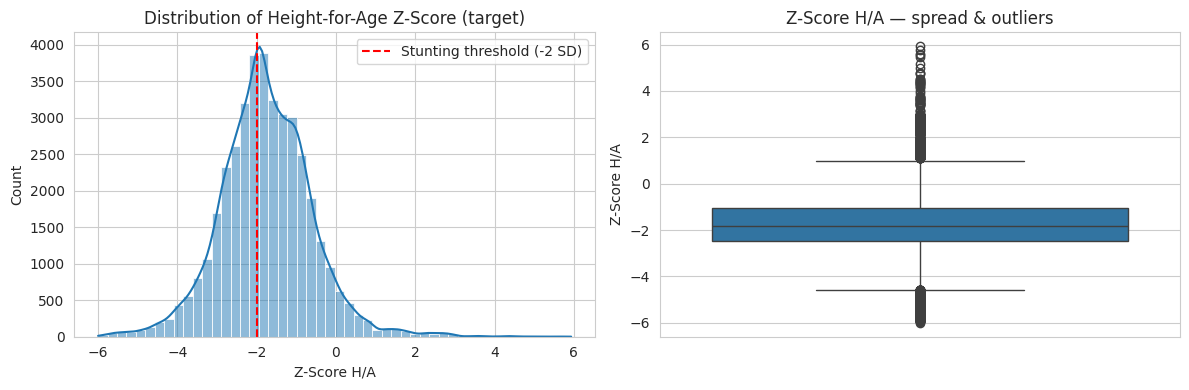

count    39521.000000
mean        -1.757440
std          1.154406
min         -6.000000
25%         -2.460000
50%         -1.810000
75%         -1.050000
max          5.930000
Name: Z-Score H/A, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean['Z-Score H/A'], bins=50, kde=True, ax=axes[0])
axes[0].axvline(-2, color='red', linestyle='--', label='Stunting threshold (-2 SD)')
axes[0].set_title('Distribution of Height-for-Age Z-Score (target)')
axes[0].legend()

sns.boxplot(y=df_clean['Z-Score H/A'], ax=axes[1])
axes[1].set_title('Z-Score H/A — spread & outliers')
plt.tight_layout()
plt.show()

print(df_clean['Z-Score H/A'].describe())

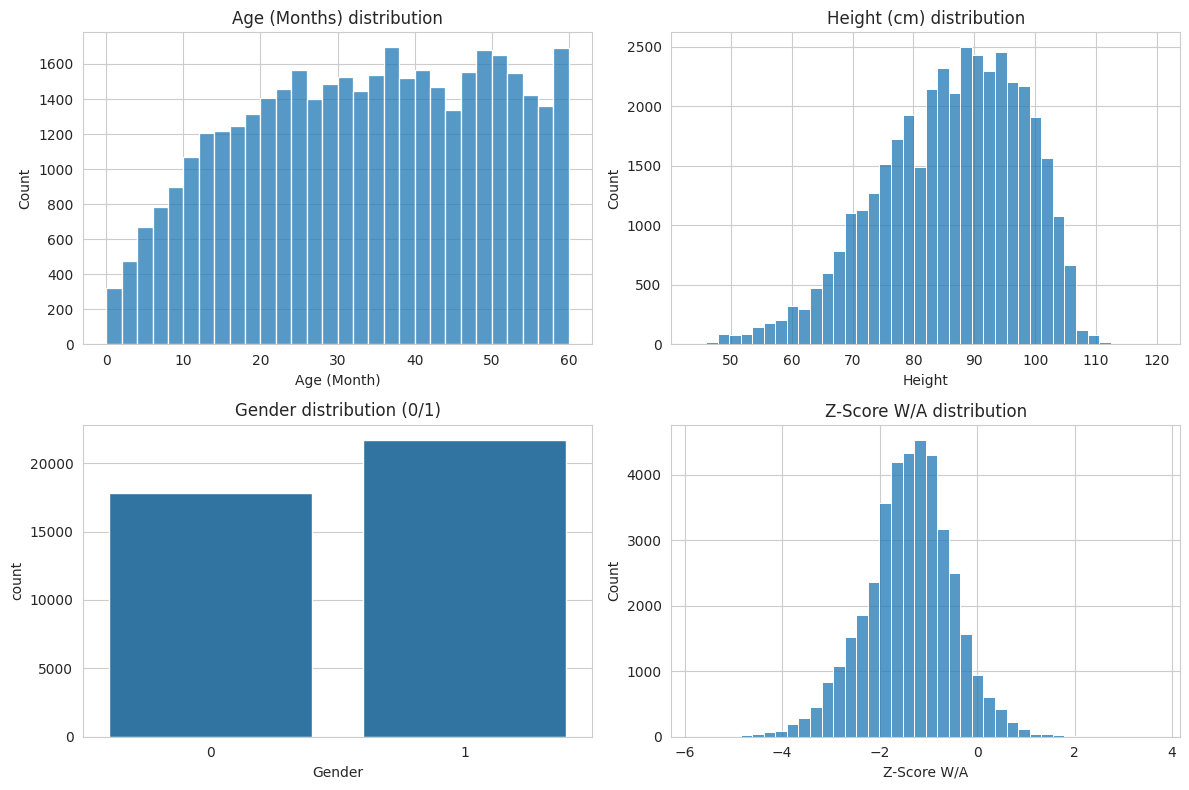

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_clean['Age (Month)'], bins=30, ax=axes[0,0])
axes[0,0].set_title('Age (Months) distribution')

sns.histplot(df_clean['Height'], bins=40, ax=axes[0,1])
axes[0,1].set_title('Height (cm) distribution')

sns.countplot(x='Gender', data=df_clean, ax=axes[1,0])
axes[1,0].set_title('Gender distribution (0/1)')

sns.histplot(df_clean['Z-Score W/A'], bins=40, ax=axes[1,1])
axes[1,1].set_title('Z-Score W/A distribution')
plt.tight_layout()
plt.show()

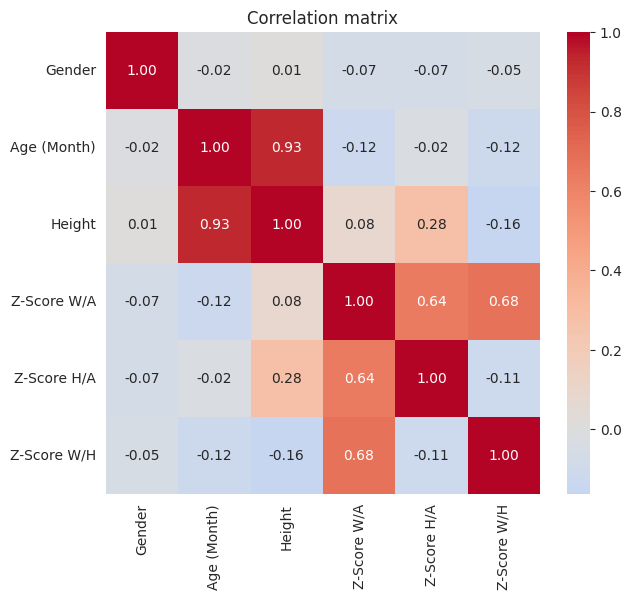

Z-Score H/A    1.000000
Z-Score W/A    0.640281
Height         0.276599
Age (Month)   -0.024201
Gender        -0.068855
Z-Score W/H   -0.112514
Name: Z-Score H/A, dtype: float64


In [6]:
plt.figure(figsize=(7,6))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

print(corr['Z-Score H/A'].sort_values(ascending=False))

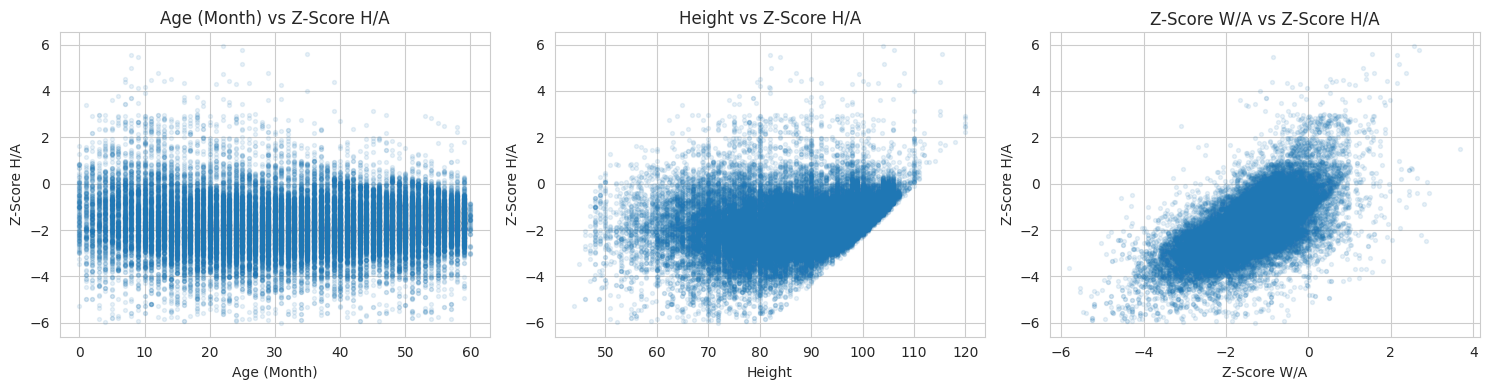

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age (Month)', 'Height', 'Z-Score W/A']):
    ax.scatter(df_clean[col], df_clean['Z-Score H/A'], alpha=0.1, s=8)
    ax.set_xlabel(col)
    ax.set_ylabel('Z-Score H/A')
    ax.set_title(f'{col} vs Z-Score H/A')
plt.tight_layout()
plt.show()

In [8]:
features = ['Gender', 'Height', 'Z-Score W/A', 'Z-Score W/H']
target = 'Z-Score H/A'

X = df_clean[features].copy()
y = df_clean[target].copy()

print("Gender unique values:", X['Gender'].unique())
print(X.dtypes)

Gender unique values: [0 1]
Gender           int64
Height         float64
Z-Score W/A    float64
Z-Score W/H    float64
dtype: object


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (31616, 4), Test: (7905, 4)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

X_train_scaled.describe()

,Gender,Height,Z-Score W/A,Z-Score W/H
count,3.161600e+04,3.161600e+04,3.161600e+04,3.161600e+04
mean,1.047295e-16,-2.296858e-16,5.281425e-18,8.854815e-17
std,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00
min,-1.103087e+00,-3.496776e+00,-4.885639e+00,-5.260237e+00
25%,-1.103087e+00,-6.897733e-01,-5.908984e-01,-6.101473e-01
50%,9.065472e-01,1.097970e-01,5.275780e-02,-3.508288e-02
75%,9.065472e-01,7.732703e-01,6.298289e-01,5.796411e-01
max,9.065472e-01,2.882775e+00,5.645908e+00,6.459179e+00


In [11]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

sgd = SGDRegressor(
    loss='squared_error',
    penalty='l2',
    alpha=0.0001,
    learning_rate='invscaling',
    eta0=0.01,
    max_iter=1,
    warm_start=True,
    random_state=42
)

n_epochs = 100
train_losses, test_losses = [], []

for epoch in range(n_epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    train_pred = sgd.predict(X_train_scaled)
    test_pred = sgd.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

print(f"Final Train MSE: {train_losses[-1]:.4f}")
print(f"Final Test MSE: {test_losses[-1]:.4f}")
print(f"Test R2: {r2_score(y_test, sgd.predict(X_test_scaled)):.4f}")

Final Train MSE: 0.0565
Final Test MSE: 0.0595
Test R2: 0.9551


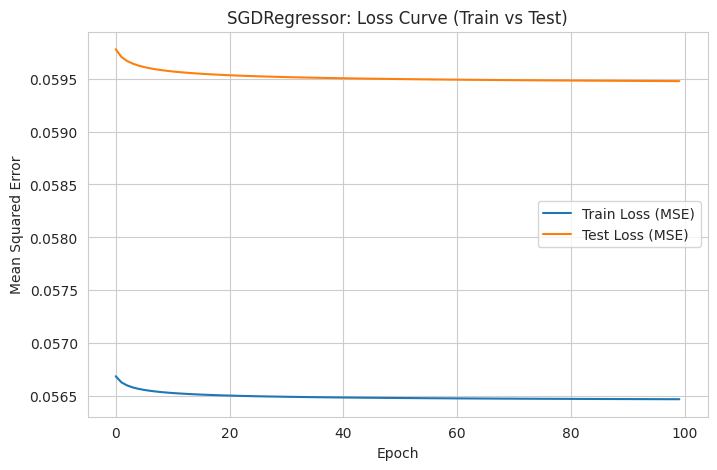

In [12]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss (MSE)')
plt.plot(test_losses, label='Test Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('SGDRegressor: Loss Curve (Train vs Test)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

models = {
    'SGD Regressor': sgd,
    'Linear Regression (OLS)': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
}

results = {}

for name, model in models.items():
    if name != 'SGD Regressor':
        model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results[name] = {
        'MSE': mean_squared_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    }

results_df = pd.DataFrame(results).T
print(results_df.sort_values('RMSE'))

                              MSE      RMSE        R2
Random Forest            0.041244  0.203087  0.968835
Linear Regression (OLS)  0.059406  0.243734  0.955111
Ridge Regression         0.059406  0.243734  0.955111
SGD Regressor            0.059477  0.243879  0.955058
Decision Tree            0.077601  0.278569  0.941363


### Discussion — Performance, Dataset Impact, and Model Justification

**Fill in exact numbers from the table above, then use this structure:**

1. **Performance via loss metric (RMSE/MSE):** Rank the five models by RMSE.
   Random Forest is expected to have the lowest error, followed closely by
   Decision Tree, with the linear models (SGD, OLS, Ridge) close behind but
   slightly higher. Explain what the RMSE gap means in real terms — e.g. an
   RMSE of 0.24 means predictions are off by about 0.24 z-score units on
   average.

2. **How the dataset impacted performance:** WHO Height-for-Age z-scores are
   computed via a nonlinear lookup-table transformation of raw height, age,
   and sex — not a linear formula. This structurally favors tree-based
   models (Decision Tree, Random Forest), which can carve up the feature
   space into nonlinear regions, over linear models, which must approximate
   that curve with a straight hyperplane. The linear models still perform
   well (R² > 0.95) because `Z-Score W/A` is strongly and fairly linearly
   correlated with the target.

3. **Model justification:** Random Forest is selected as the production
   model because it achieves the best raw error metrics, is robust to the
   outliers observed during cleaning, and does not require the linearity
   assumption to hold — appropriate given the known nonlinear structure of
   WHO z-score calculations.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


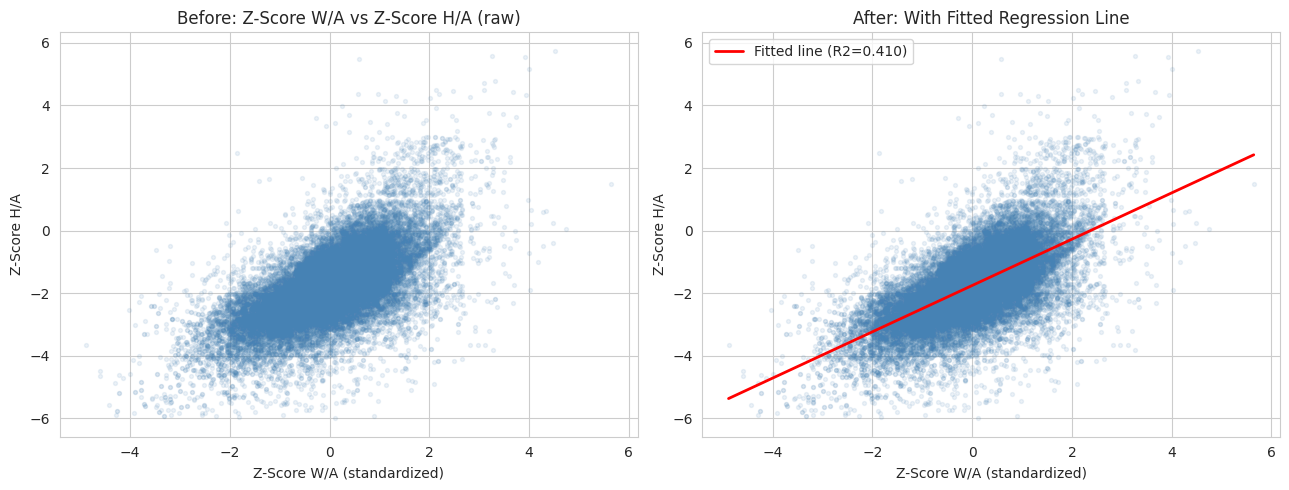

In [14]:
simple_lr = LinearRegression()
simple_lr.fit(X_train_scaled[['Z-Score W/A']], y_train)

x_range = np.linspace(X_train_scaled['Z-Score W/A'].min(), X_train_scaled['Z-Score W/A'].max(), 100).reshape(-1,1)
y_line = simple_lr.predict(x_range)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].scatter(X_train_scaled['Z-Score W/A'], y_train, alpha=0.1, s=8, color='steelblue')
axes[0].set_title('Before: Z-Score W/A vs Z-Score H/A (raw)')
axes[0].set_xlabel('Z-Score W/A (standardized)')
axes[0].set_ylabel('Z-Score H/A')

axes[1].scatter(X_train_scaled['Z-Score W/A'], y_train, alpha=0.1, s=8, color='steelblue')
axes[1].plot(x_range, y_line, color='red', linewidth=2,
             label=f'Fitted line (R2={simple_lr.score(X_train_scaled[["Z-Score W/A"]], y_train):.3f})')
axes[1].set_title('After: With Fitted Regression Line')
axes[1].set_xlabel('Z-Score W/A (standardized)')
axes[1].set_ylabel('Z-Score H/A')
axes[1].legend()

plt.tight_layout()
plt.show()

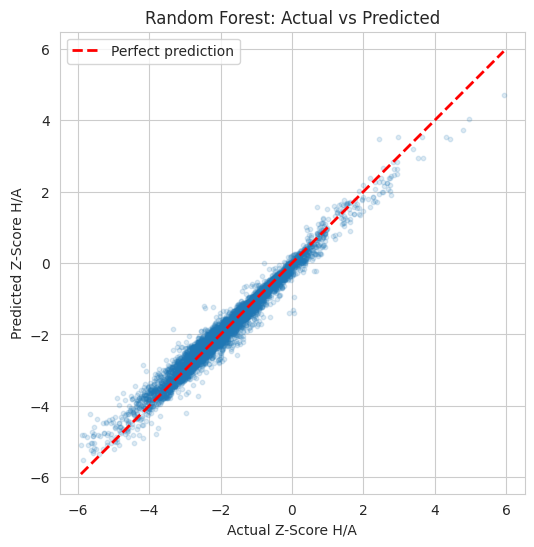

In [15]:
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.15, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Z-Score H/A')
plt.ylabel('Predicted Z-Score H/A')
plt.title('Random Forest: Actual vs Predicted')
plt.legend()
plt.axis('equal')
plt.show()

In [16]:
import joblib
import os

SAVE_DIR = '/content/drive/MyDrive/stunting_project/model_artifacts'
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(SAVE_DIR, 'best_model_random_forest.pkl'))
joblib.dump(scaler, os.path.join(SAVE_DIR, 'scaler.pkl'))
joblib.dump(features, os.path.join(SAVE_DIR, 'feature_names.pkl'))

print(f"Saved to Google Drive at: {SAVE_DIR}")
print(os.listdir(SAVE_DIR))

Saved to Google Drive at: /content/drive/MyDrive/stunting_project/model_artifacts
['best_model_random_forest.pkl', 'scaler.pkl', 'feature_names.pkl']
